# Project Sentinel — Fraud Ring Analysis

## tl;dr

Run the pipeline first; this notebook derives its findings from the generated silver and gold artifacts.

## Context & Methods

Show how shared device, payout, and network entities expose coordination that row-level classifiers miss.

### Key Assumptions

Synthetic telemetry is deterministic and illustrative; IEEE-CIS labels remain the supervised target.

## Data

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
rings=pd.read_csv(ROOT/'data/gold/graph/fraud_rings.csv')
rings.groupby('ring_id').ring_size.max().nlargest(10).to_frame()

,ring_size
ring_id,
R00001,800


## Results

Text(0.5, 0, 'Drivers per component')

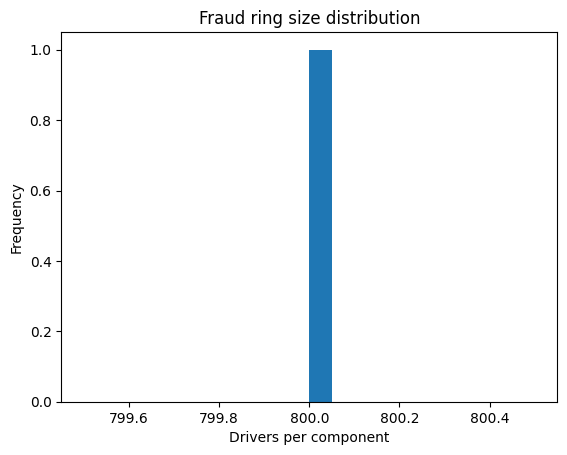

In [2]:
rings.groupby('ring_id').ring_size.max().plot.hist(bins=20, title='Fraud ring size distribution'); plt.xlabel('Drivers per component')

C:\Users\mahes\AppData\Local\Temp\ipykernel_33764\2131256832.py:13: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.savefig(ROOT/'dashboards/case_001_graph.png',dpi=180,bbox_inches='tight'); plt.show()


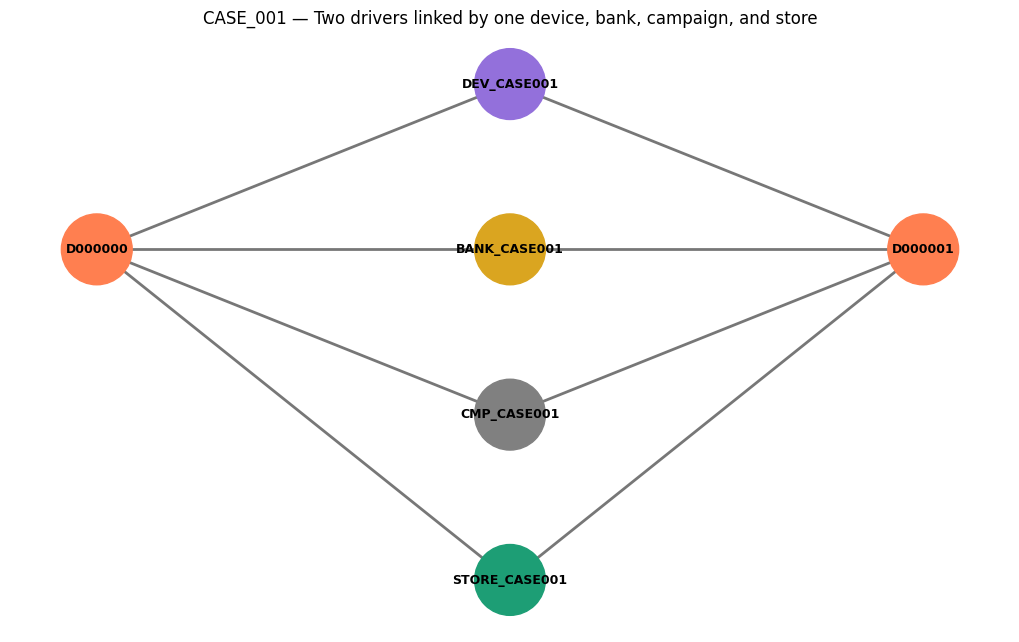

In [3]:
trips=pd.read_parquet(ROOT/'data/silver/spark_driver_trips.parquet')
case_rows=trips[trips.device_id.eq('DEV_CASE001')]
drivers=sorted(case_rows.driver_id.unique())[:2]
case_graph=nx.Graph()
for driver in drivers:
    case_graph.add_node(driver, kind='driver')
    for entity,kind in [('DEV_CASE001','device'),('BANK_CASE001','bank'),('CMP_CASE001','campaign'),('STORE_CASE001','store')]:
        case_graph.add_node(entity, kind=kind); case_graph.add_edge(driver, entity)
colors={'driver':'coral','device':'mediumpurple','bank':'goldenrod','campaign':'gray','store':'#1D9E75'}
pos={'DEV_CASE001':(0,1),'BANK_CASE001':(0,0),'CMP_CASE001':(0,-1),'STORE_CASE001':(0,-2),drivers[0]:(-1,0),drivers[1]:(1,0)}
plt.figure(figsize=(10,6)); nx.draw(case_graph,pos,with_labels=True,node_size=2600,font_size=9,font_weight='bold',node_color=[colors[case_graph.nodes[n]['kind']] for n in case_graph],edge_color='#777',width=2)
plt.title('CASE_001 — Two drivers linked by one device, bank, campaign, and store')
plt.tight_layout(); plt.savefig(ROOT/'dashboards/case_001_graph.png',dpi=180,bbox_inches='tight'); plt.show()

### CASE_001 interpretation

Two driver accounts converge on the same device, payout account, incentive campaign, and delivery store. Each row can look individually plausible, but the entity graph exposes coordinated control and cash-out infrastructure—precisely the pattern a row-based classifier can miss.

## Takeaways

The graph adds value when independent identifiers converge. Shared IP or household infrastructure alone is insufficient evidence and should remain corroborative.